# 5. Model Building

This notebook develops and compares baseline machine learning models for emotion classification using the TF-IDF features generated during feature engineering.

The models will be trained using the training dataset and compared using the validation dataset.

The test dataset will remain untouched until the final evaluation stage.

### Models to be evaluated

- Logistic Regression
- Linear Support Vector Machine (Linear SVM)
- Multinomial Naive Bayes

The best-performing model or models will be carried forward to hyperparameter tuning.

In [1]:
import os
import numpy as np

from scipy.sparse import load_npz

# Load TF-IDF feature matrices
X_train = load_npz("../data/processed/X_train_tfidf.npz")
X_val = load_npz("../data/processed/X_val_tfidf.npz")
X_test = load_npz("../data/processed/X_test_tfidf.npz")

# Load target labels
y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Test features:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

print("\nFeature matrix type:", type(X_train))

Training features: (15999, 32992)
Validation features: (2000, 32992)
Test features: (2000, 32992)

Training labels: (15999,)
Validation labels: (2000,)
Test labels: (2000,)

Feature matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [2]:
#  Verifying Target Label Distribution

from collections import Counter

train_distribution = Counter(y_train)
val_distribution = Counter(y_val)

print("Training label distribution:")
for label in sorted(train_distribution):
    print(f"Label {label}: {train_distribution[label]}")

print("\nValidation label distribution:")
for label in sorted(val_distribution):
    print(f"Label {label}: {val_distribution[label]}")

Training label distribution:
Label 0: 4666
Label 1: 5361
Label 2: 1304
Label 3: 2159
Label 4: 1937
Label 5: 572

Validation label distribution:
Label 0: 550
Label 1: 704
Label 2: 178
Label 3: 275
Label 4: 212
Label 5: 81


In [3]:
# Logistic Regression Baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logreg_model.fit(X_train, y_train)

y_val_pred_logreg = logreg_model.predict(X_val)

logreg_accuracy = accuracy_score(y_val, y_val_pred_logreg)

print(f"Validation Accuracy: {logreg_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_logreg,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

Validation Accuracy: 0.8755

Classification Report:
              precision    recall  f1-score   support

     sadness       0.92      0.88      0.90       550
         joy       0.92      0.88      0.90       704
        love       0.75      0.93      0.83       178
       anger       0.88      0.89      0.88       275
        fear       0.81      0.82      0.81       212
    surprise       0.73      0.80      0.76        81

    accuracy                           0.88      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.88      0.88      0.88      2000



In [4]:
#  Linear Support Vector Machine Baseline

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train, y_train)

y_val_pred_svm = svm_model.predict(X_val)

svm_accuracy = accuracy_score(y_val, y_val_pred_svm)

print(f"Validation Accuracy: {svm_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_svm,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

Validation Accuracy: 0.9030

Classification Report:
              precision    recall  f1-score   support

     sadness       0.93      0.93      0.93       550
         joy       0.93      0.92      0.92       704
        love       0.80      0.88      0.84       178
       anger       0.92      0.90      0.91       275
        fear       0.88      0.83      0.86       212
    surprise       0.77      0.79      0.78        81

    accuracy                           0.90      2000
   macro avg       0.87      0.88      0.87      2000
weighted avg       0.90      0.90      0.90      2000



In [5]:
#  Multinomial Naive Bayes Baseline

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_val_pred_nb = nb_model.predict(X_val)

nb_accuracy = accuracy_score(y_val, y_val_pred_nb)

print(f"Validation Accuracy: {nb_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_nb,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

Validation Accuracy: 0.6295

Classification Report:
              precision    recall  f1-score   support

     sadness       0.68      0.87      0.76       550
         joy       0.58      0.99      0.73       704
        love       1.00      0.03      0.05       178
       anger       0.96      0.17      0.28       275
        fear       0.95      0.17      0.29       212
    surprise       0.00      0.00      0.00        81

    accuracy                           0.63      2000
   macro avg       0.69      0.37      0.35      2000
weighted avg       0.71      0.63      0.54      2000



c:\Users\SINAN P SALIM\OneDrive\Desktop\Project\text-emotion-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SINAN P SALIM\OneDrive\Desktop\Project\text-emotion-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SINAN P SALIM\OneDrive\Desktop\Project\text-emotion-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

In [9]:
import pandas as  pd

In [10]:
#  Baseline Model Comparison

from sklearn.metrics import f1_score

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred_logreg),
        accuracy_score(y_val, y_val_pred_svm),
        accuracy_score(y_val, y_val_pred_nb)
    ],
    "Macro F1": [
        f1_score(y_val, y_val_pred_logreg, average="macro"),
        f1_score(y_val, y_val_pred_svm, average="macro"),
        f1_score(y_val, y_val_pred_nb, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_val, y_val_pred_logreg, average="weighted"),
        f1_score(y_val, y_val_pred_svm, average="weighted"),
        f1_score(y_val, y_val_pred_nb, average="weighted")
    ]
})

baseline_results = baseline_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print(baseline_results.to_string(index=False))

                  Model  Accuracy  Macro F1  Weighted F1
             Linear SVM    0.9030  0.873497     0.903208
    Logistic Regression    0.8755  0.848787     0.876498
Multinomial Naive Bayes    0.6295  0.352750     0.540096


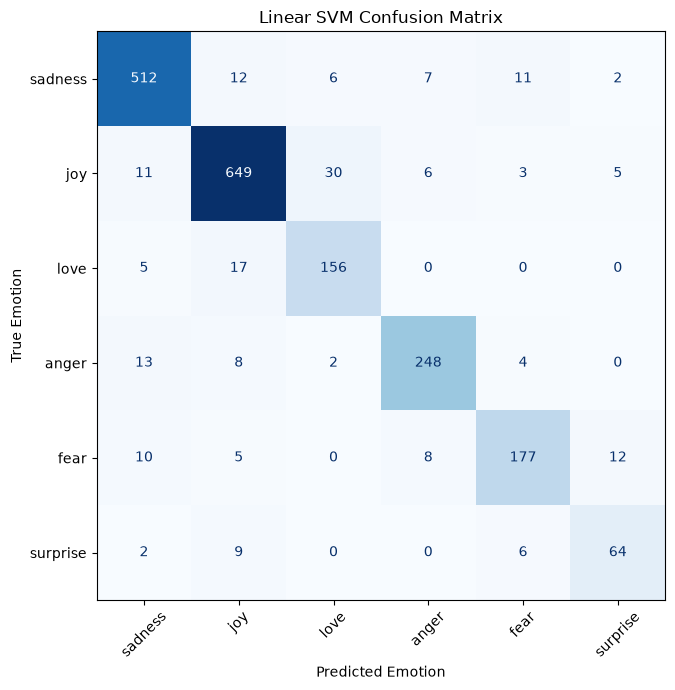

In [11]:
#  Linear SVM Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

emotion_names = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
]

cm_svm = confusion_matrix(
    y_val,
    y_val_pred_svm,
    labels=[0, 1, 2, 3, 4, 5]
)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=emotion_names
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
## Saving Baseline Model Results

baseline_summary = {
    "Logistic Regression": {
        "accuracy": accuracy_score(y_val, y_val_pred_logreg),
        "macro_f1": f1_score(y_val, y_val_pred_logreg, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred_logreg, average="weighted")
    },
    "Linear SVM": {
        "accuracy": accuracy_score(y_val, y_val_pred_svm),
        "macro_f1": f1_score(y_val, y_val_pred_svm, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred_svm, average="weighted")
    },
    "Multinomial Naive Bayes": {
        "accuracy": accuracy_score(y_val, y_val_pred_nb),
        "macro_f1": f1_score(y_val, y_val_pred_nb, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred_nb, average="weighted")
    }
}

print("Baseline results saved in memory:")
for model, metrics in baseline_summary.items():
    print(
        f"{model}: "
        f"Accuracy={metrics['accuracy']:.4f}, "
        f"Macro F1={metrics['macro_f1']:.4f}, "
        f"Weighted F1={metrics['weighted_f1']:.4f}"
    )

Baseline results saved in memory:
Logistic Regression: Accuracy=0.8755, Macro F1=0.8488, Weighted F1=0.8765
Linear SVM: Accuracy=0.9030, Macro F1=0.8735, Weighted F1=0.9032
Multinomial Naive Bayes: Accuracy=0.6295, Macro F1=0.3527, Weighted F1=0.5401


##  Model Building Summary

Three baseline machine learning models were trained and evaluated using the validation dataset:

- Logistic Regression
- Linear Support Vector Machine (Linear SVM)
- Multinomial Naive Bayes

Linear SVM achieved the strongest validation performance with:

- Accuracy: 90.30%
- Macro F1-score: 0.8735
- Weighted F1-score: 0.9032

Logistic Regression provided a competitive secondary baseline, while Multinomial Naive Bayes performed substantially worse on the imbalanced emotion classification task.

Based on the validation results, Linear SVM was selected as the primary candidate for hyperparameter tuning.

The test dataset was not used for model selection and will remain untouched until final evaluation.